In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn. preprocessing import PolynomialFeatures
from sklearn. linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv("Oilwell.csv")
x = df.iloc[:, [8]].values
y = df.iloc[:, 1].values

In [3]:
#split into training and test sets
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.2, random_state = 42 )

In [4]:
print(y_train)

[32 26 16 ... 16 13 20]


In [5]:
#Transform features to polynomial
degree = 2
poly_features = PolynomialFeatures(degree=degree)
x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)

In [6]:
#Train the model 
regressor = LinearRegression()
regressor.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
#predict 
y_pred = regressor.predict(x_test_poly)

In [8]:
mse=mean_squared_error(y_test, y_pred) 
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"polynomial Degree : {degree}")  
print(f"MSE : {mse:.4f}")
print(f"RSME : {rmse:.4f}")
print(f"R2 score :{r2:.4f}")


polynomial Degree : 2
MSE : 17.5216
RSME : 4.1859
R2 score :0.8136


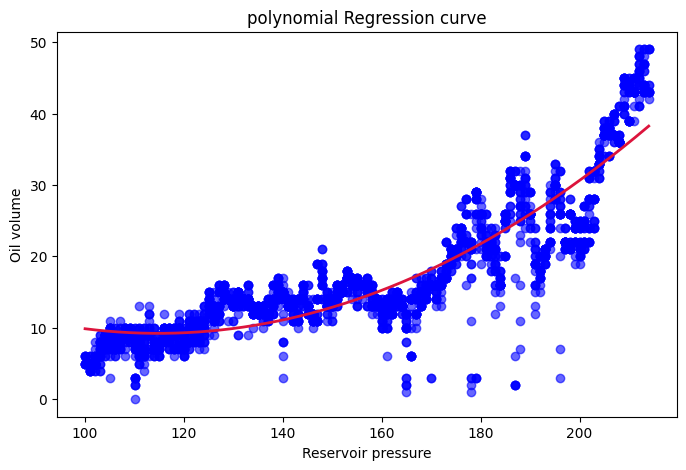

In [9]:
#PLOT (works well when x has a single feature)
if x.shape [1] ==1: 
    x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
    x_range_poly = poly_features.transform(x_range)
    y_range_pred = regressor.predict(x_range_poly)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(x,y, color = "blue", alpha = 0.6, label = "Reservoir pressure")
    plt.plot(x_range, y_range_pred, color = 'crimson', lw= 2, label = f'Degree-{degree} fit')
    plt.xlabel("Reservoir pressure")
    plt.ylabel("Oil volume")
    plt.title("polynomial Regression curve")